In [39]:
# Clustering Materials – Unsupervised Learning

# In this notebook, we apply clustering techniques to group materials based on their physical properties.

## Objectives
#- Identify natural groupings in the dataset
#- Explore relationships between features
#- Visualize clusters in 2D space

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df = pd.read_csv("../data/processed/materials_features.csv")

In [41]:
# Feature selection

# I select numerical features relevant for clustering.

X = df.select_dtypes(include=["int64", "float64"]).copy()

# Remove target-like or leakage features
X = X.drop(columns=[
    "is_metal",
    "is_metal_from_gap",
    "metal_consistency"
], errors="ignore")

X.head()

,density,formation_energy_per_atom,energy_above_hull,band_gap,num_elements,band_gap_log,formation_energy_abs,density_log,density_bandgap_ratio,energy_density_product
0,8.157868,0.021639,0.021639,0.0,1,0.0,0.021639,2.214613,8.157868e+06,0.176529
1,8.313274,0.015586,0.015586,0.0,1,0.0,0.015586,2.231441,8.313274e+06,0.129569
2,8.144760,0.011822,0.011822,0.0,1,0.0,0.011822,2.213181,8.144760e+06,0.096285
3,8.170182,0.000000,0.000000,0.0,1,0.0,0.000000,2.215957,8.170182e+06,0.000000
4,11.367264,-0.413285,0.087118,0.0,2,0.0,0.413285,2.515053,1.136726e+07,-4.697923


In [42]:
# Feature scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

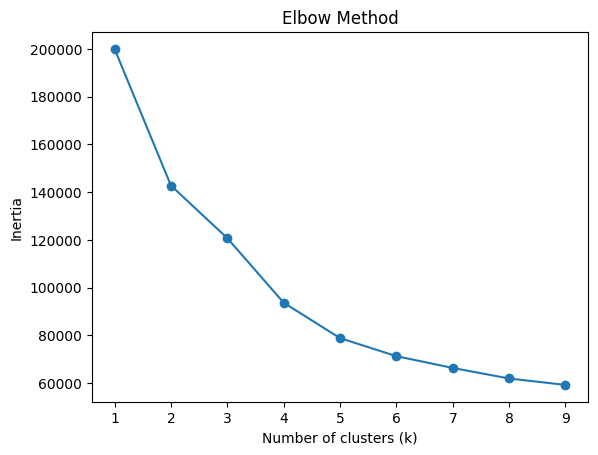

In [43]:
# Elbow method

inertia = []

k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [44]:
# KMeans clustering

k = 4  # based on elbow

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

In [45]:
# PCA for visualization

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["pca1"] = X_pca[:, 0]
df["pca2"] = X_pca[:, 1]



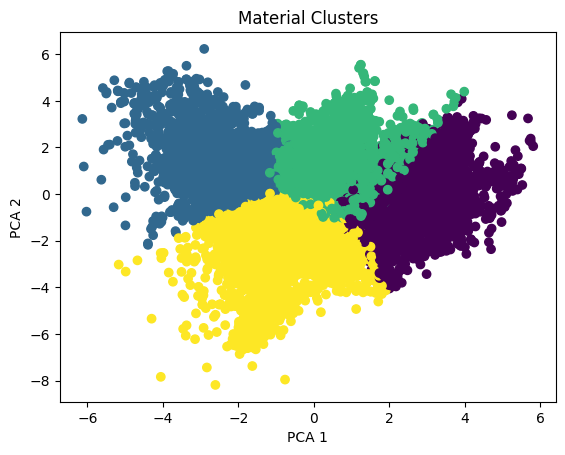

In [46]:
# Cluster visualization

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Material Clusters")
plt.show()

In [47]:
df.dtypes

formula_pretty                  object
density                        float64
material_id                     object
formation_energy_per_atom      float64
energy_above_hull              float64
band_gap                       float64
is_metal                          bool
fields_not_requested            object
num_elements                     int64
band_gap_log                   float64
is_stable                         bool
formation_energy_abs           float64
density_log                    float64
density_bandgap_ratio          float64
energy_density_product         float64
metal_consistency                 bool
material_type_insulator           bool
material_type_metal               bool
material_type_semiconductor       bool
density_category_low              bool
density_category_medium           bool
density_category_high             bool
cluster                          int32
pca1                           float64
pca2                           float64
dtype: object

In [48]:
# Cluster analysis

df.groupby("cluster").mean(numeric_only=True)

,density,formation_energy_per_atom,energy_above_hull,band_gap,is_metal,num_elements,band_gap_log,is_stable,formation_energy_abs,density_log,...,energy_density_product,metal_consistency,material_type_insulator,material_type_metal,material_type_semiconductor,density_category_low,density_category_medium,density_category_high,pca1,pca2
cluster,,,,,,,,,,,,,,,,,,,,,
0,4.372221,-2.576417,0.045247,3.400722,0.000000,3.292906,1.437755,0.0,2.576418,1.636600,...,-11.559030,1.0,0.854587,0.000000,0.145413,0.437903,0.391304,0.170793,2.623383,-0.065601
1,8.061155,-0.439818,0.098258,0.022919,0.946452,2.535252,0.017079,0.0,0.515538,2.174561,...,-3.432728,1.0,0.000223,0.946452,0.053324,0.000000,0.167336,0.832664,-2.416224,1.099817
2,5.421074,-2.368857,0.116659,0.280197,0.573218,3.392486,0.197042,0.0,2.368857,1.831944,...,-12.785650,1.0,0.000771,0.573218,0.426012,0.170906,0.461272,0.367823,0.558938,1.067058
3,3.238082,-0.334630,0.440998,0.681796,0.452092,2.621808,0.384392,0.0,0.764052,1.370836,...,-1.562563,1.0,0.119000,0.452092,0.428908,0.665640,0.297229,0.037131,-0.848030,-1.838810


In [49]:
df.columns

Index(['formula_pretty', 'density', 'material_id', 'formation_energy_per_atom',
       'energy_above_hull', 'band_gap', 'is_metal', 'fields_not_requested',
       'num_elements', 'band_gap_log', 'is_stable', 'formation_energy_abs',
       'density_log', 'density_bandgap_ratio', 'energy_density_product',
       'metal_consistency', 'material_type_insulator', 'material_type_metal',
       'material_type_semiconductor', 'density_category_low',
       'density_category_medium', 'density_category_high', 'cluster', 'pca1',
       'pca2'],
      dtype='object')

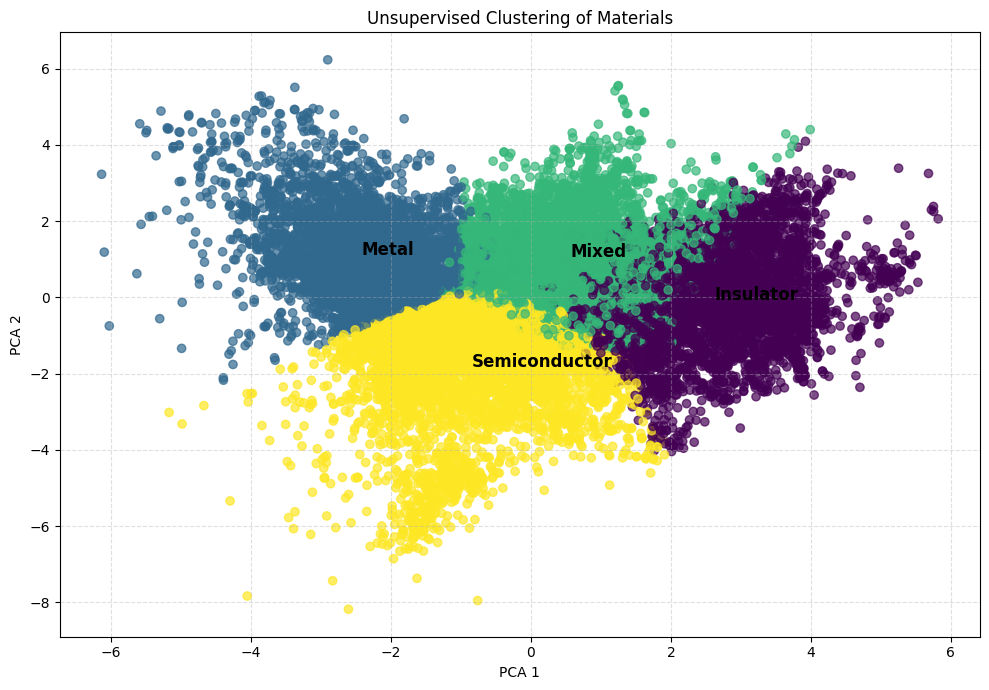

In [50]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["cluster"],
    alpha=0.7
)

# Annotate cluster centers
for i in range(4):
    center_x = X_pca[df["cluster"] == i, 0].mean()
    center_y = X_pca[df["cluster"] == i, 1].mean()
    plt.text(center_x, center_y, cluster_map[i],
             fontsize=12, weight='bold')

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Unsupervised Clustering of Materials")

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

In [51]:
import sys
!{sys.executable} -m pip install nbformat


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
# preparing formulas with subscripts

import re

def format_formula(formula):
    # Replace numbers with subscript HTML
    return re.sub(r'(\d+)', r'<sub>\1</sub>', formula)

df["formula_html"] = df["formula_pretty"].apply(format_formula)

In [53]:
import plotly.express as px

# Make sure you have identifiers
# If you have material_id, use it
# Otherwise use index
#df["material_id"] = df.index.astype(str)

# Create interactive plot

df["cluster_label"] = df["cluster"].apply(lambda x: f"Cluster {x+1}")

fig = px.scatter(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    color=df["cluster_label"].astype(str),
    hover_name=df["formula_html"],
    hover_data={
                "material_id": df["material_id"],
        "band_gap": df["band_gap"],
        "density": df["density"],
        "formation_energy_per_atom": df["formation_energy_per_atom"]
    },
    labels={"x": "PCA 1", "y": "PCA 2"},

    title="Interactive Clustering of Materials"
)

fig.show()

In [54]:
fig.write_html("materials_clusters.html")

In [55]:
df.columns

Index(['formula_pretty', 'density', 'material_id', 'formation_energy_per_atom',
       'energy_above_hull', 'band_gap', 'is_metal', 'fields_not_requested',
       'num_elements', 'band_gap_log', 'is_stable', 'formation_energy_abs',
       'density_log', 'density_bandgap_ratio', 'energy_density_product',
       'metal_consistency', 'material_type_insulator', 'material_type_metal',
       'material_type_semiconductor', 'density_category_low',
       'density_category_medium', 'density_category_high', 'cluster', 'pca1',
       'pca2', 'formula_html', 'cluster_label'],
      dtype='object')

In [56]:
# Save clustering dataset

df.to_csv("../data/processed/materials_clustering.csv", index=False)

In [57]:
df.head(10)

,formula_pretty,density,material_id,formation_energy_per_atom,energy_above_hull,band_gap,is_metal,fields_not_requested,num_elements,band_gap_log,...,material_type_metal,material_type_semiconductor,density_category_low,density_category_medium,density_category_high,cluster,pca1,pca2,formula_html,cluster_label
0,Ac,8.157868,mp-ovi,0.021639,0.021639,0.0,True,"['builder_meta', 'nsites', 'elements', 'neleme...",1,0.0,...,True,False,False,False,True,1,-3.503865,0.628548,Ac,Cluster 2
1,Ac,8.313274,mp-cpicf,0.015586,0.015586,0.0,True,"['builder_meta', 'nsites', 'elements', 'neleme...",1,0.0,...,True,False,False,False,True,1,-3.533601,0.701271,Ac,Cluster 2
2,Ac,8.144760,mp-cpicr,0.011822,0.011822,0.0,True,"['builder_meta', 'nsites', 'elements', 'neleme...",1,0.0,...,True,False,False,False,True,1,-3.495146,0.635550,Ac,Cluster 2
3,Ac,8.170182,mp-bxcek,0.000000,0.000000,0.0,True,"['builder_meta', 'nsites', 'elements', 'neleme...",1,0.0,...,True,False,False,False,True,1,-3.493494,0.661285,Ac,Cluster 2
4,Ac2AgIr,11.367264,mp-bxatg,-0.413285,0.087118,0.0,True,"['builder_meta', 'nsites', 'elements', 'neleme...",2,0.0,...,True,False,False,False,True,1,-3.337902,2.472436,Ac<sub>2</sub>AgIr,Cluster 2
5,Ac2AgPb,9.490476,mp-cpicy,-0.480278,0.000000,0.0,True,"['builder_meta', 'nsites', 'elements', 'neleme...",2,0.0,...,True,False,False,False,True,1,-2.887685,1.813477,Ac<sub>2</sub>AgPb,Cluster 2
6,Ac2Br2O,3.512584,mp-cqryn,-1.460073,1.242844,0.0,True,"['builder_meta', 'nsites', 'elements', 'neleme...",3,0.0,...,True,False,True,False,False,3,-0.824572,-1.282136,Ac<sub>2</sub>Br<sub>2</sub>O,Cluster 4
7,Ac2CdGa,8.243210,mp-cpicq,-0.402831,0.027137,0.0,True,"['builder_meta', 'nsites', 'elements', 'neleme...",3,0.0,...,True,False,False,False,True,1,-2.409673,1.359265,Ac<sub>2</sub>CdGa,Cluster 2
8,Ac2CdGe,8.449542,mp-cpicl,-0.464809,0.059054,0.0,True,"['builder_meta', 'nsites', 'elements', 'neleme...",3,0.0,...,True,False,False,False,True,1,-2.389890,1.478925,Ac<sub>2</sub>CdGe,Cluster 2
9,Ac2CdHg,9.570977,mp-cpidi,-0.433682,0.000000,0.0,True,"['builder_meta', 'nsites', 'elements', 'neleme...",3,0.0,...,True,False,False,False,True,1,-2.622171,1.982321,Ac<sub>2</sub>CdHg,Cluster 2
